# Window mean relative RPKM

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

folder = '/cta/users/guneyn23/relative_repair'
columns = ['chrom', 'start', 'end', 'peak', 'count', 'relative_rpkm']

In [2]:
def make_summary(real_file, sim_file):
    real_sum = [0.0] * 401
    real_count = [0] * 401
    sim_sum = [0.0] * 401
    sim_count = [0] * 401

    with open(real_file) as file:
        for line in file:
            values = line.rstrip('\n').split('\t')
            window = int(values[3].split('_')[-1])
            if len(values) < 6 or values[5] == '':
                continue
            rpkm = float(values[5])
            if not math.isfinite(rpkm):
                continue

            real_sum[window] = real_sum[window] + rpkm
            real_count[window] = real_count[window] + 1

    with open(sim_file) as file:
        for line in file:
            values = line.rstrip('\n').split('\t')
            window = int(values[3].split('_')[-1])
            if len(values) < 6 or values[5] == '':
                continue
            rpkm = float(values[5])
            if not math.isfinite(rpkm):
                continue

            sim_sum[window] = sim_sum[window] + rpkm
            sim_count[window] = sim_count[window] + 1

    rows = []

    for window in range(1, 401):
        real_mean = real_sum[window] / real_count[window] if real_count[window] else float('nan')
        sim_mean = sim_sum[window] / sim_count[window] if sim_count[window] else float('nan')
        real_sim_ratio = real_mean / sim_mean if math.isfinite(sim_mean) and sim_mean != 0 else float('nan')

        rows.append({
            'window': window,
            'real_mean': real_mean,
            'sim_mean': sim_mean,
            'real_sim_ratio': real_sim_ratio
        })

    return pd.DataFrame(rows)

## CPD summary tables

In [3]:
cpd_15m = make_summary(f'{folder}/CPD_15m_real_relative_rpkm.tsv', f'{folder}/CPD_15m_sim_relative_rpkm.tsv')
cpd_30m = make_summary(f'{folder}/CPD_30m_real_relative_rpkm.tsv', f'{folder}/CPD_30m_sim_relative_rpkm.tsv')
cpd_1h = make_summary(f'{folder}/CPD_1h_real_relative_rpkm.tsv', f'{folder}/CPD_1h_sim_relative_rpkm.tsv')
cpd_4h = make_summary(f'{folder}/CPD_4h_real_relative_rpkm.tsv', f'{folder}/CPD_4h_sim_relative_rpkm.tsv')
cpd_8h = make_summary(f'{folder}/CPD_8h_real_relative_rpkm.tsv', f'{folder}/CPD_8h_sim_relative_rpkm.tsv')

cpd_15m.head()

,window,real_mean,sim_mean,real_sim_ratio
0,1,0.417861,0.507338,0.823635
1,2,0.421392,0.506350,0.832216
2,3,0.423410,0.512265,0.826545
3,4,0.423654,0.517016,0.819421
4,5,0.418402,0.502023,0.833431


## 64 summary tables

In [4]:
damage64_15m = make_summary(f'{folder}/64_15m_real_relative_rpkm.tsv', f'{folder}/64_15m_sim_relative_rpkm.tsv')
damage64_30m = make_summary(f'{folder}/64_30m_real_relative_rpkm.tsv', f'{folder}/64_30m_sim_relative_rpkm.tsv')
damage64_1h = make_summary(f'{folder}/64_1h_real_relative_rpkm.tsv', f'{folder}/64_1h_sim_relative_rpkm.tsv')
damage64_4h = make_summary(f'{folder}/64_4h_real_relative_rpkm.tsv', f'{folder}/64_4h_sim_relative_rpkm.tsv')
damage64_8h = make_summary(f'{folder}/64_8h_real_relative_rpkm.tsv', f'{folder}/64_8h_sim_relative_rpkm.tsv')

damage64_15m.head()

,window,real_mean,sim_mean,real_sim_ratio
0,1,0.523935,0.594634,0.881105
1,2,0.528451,0.591703,0.893101
2,3,0.526967,0.592053,0.890067
3,4,0.524971,0.590247,0.889409
4,5,0.531936,0.589089,0.902981


## Save summary tables

In [ ]:
cpd_15m.to_csv(f'{folder}/CPD_15m_window_summary.tsv', sep='\t', index=False)
cpd_30m.to_csv(f'{folder}/CPD_30m_window_summary.tsv', sep='\t', index=False)
cpd_1h.to_csv(f'{folder}/CPD_1h_window_summary.tsv', sep='\t', index=False)
cpd_4h.to_csv(f'{folder}/CPD_4h_window_summary.tsv', sep='\t', index=False)
cpd_8h.to_csv(f'{folder}/CPD_8h_window_summary.tsv', sep='\t', index=False)
damage64_15m.to_csv(f'{folder}/64_15m_window_summary.tsv', sep='\t', index=False)
damage64_30m.to_csv(f'{folder}/64_30m_window_summary.tsv', sep='\t', index=False)
damage64_1h.to_csv(f'{folder}/64_1h_window_summary.tsv', sep='\t', index=False)
damage64_4h.to_csv(f'{folder}/64_4h_window_summary.tsv', sep='\t', index=False)
damage64_8h.to_csv(f'{folder}/64_8h_window_summary.tsv', sep='\t', index=False)

## Plots

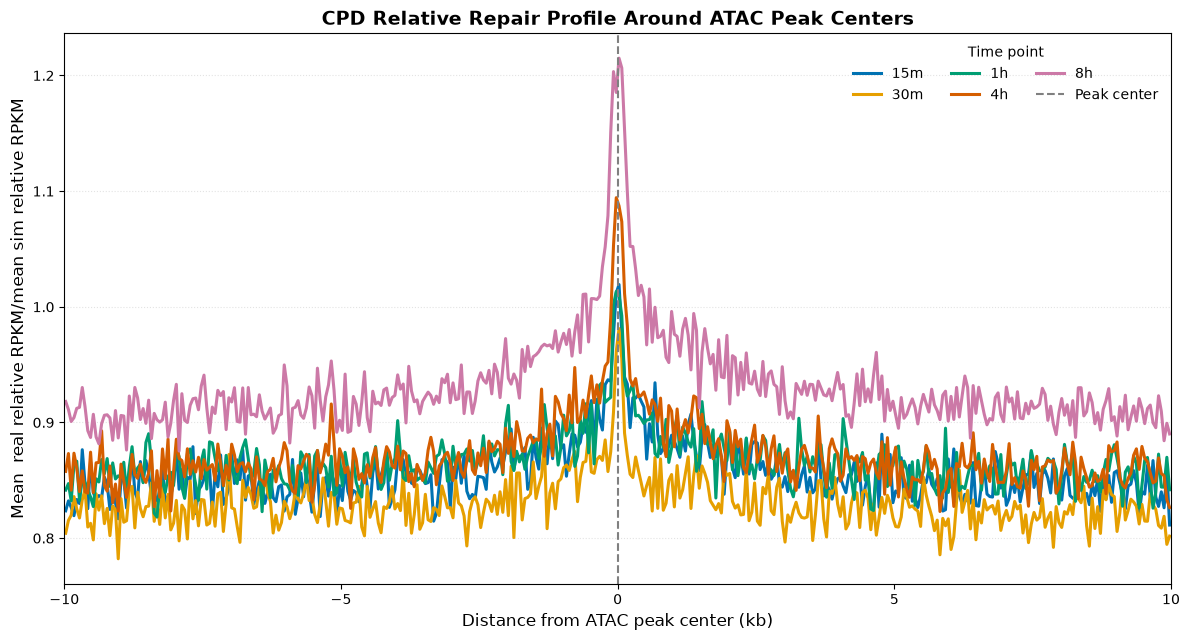

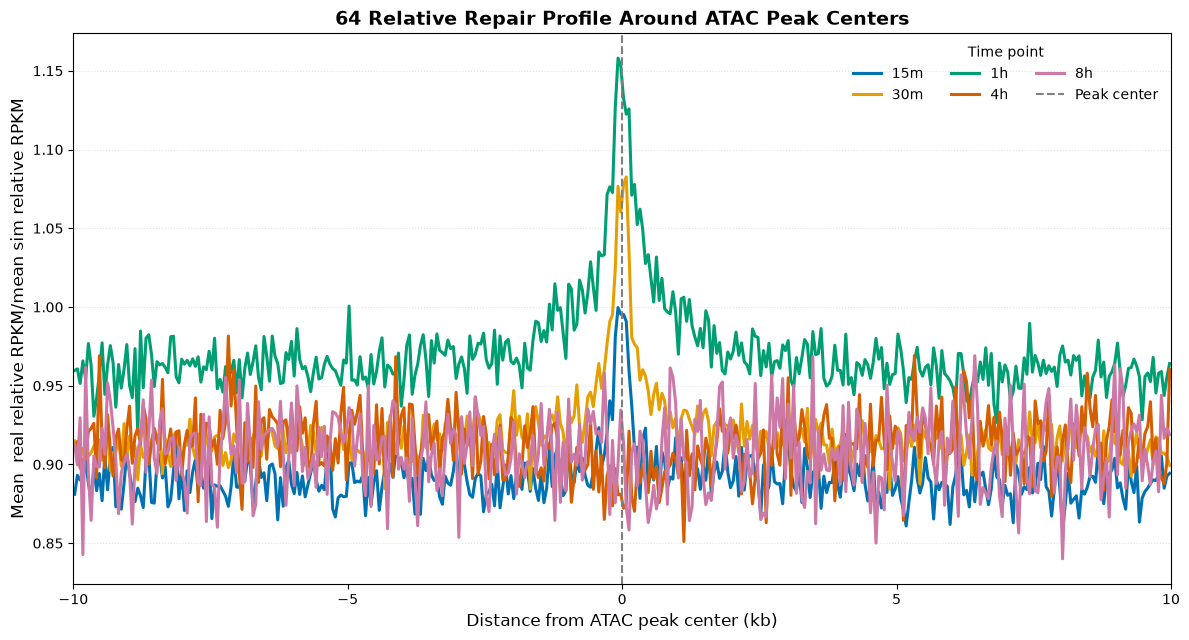

In [9]:
cpd_tables = {'15m': cpd_15m, '30m': cpd_30m, '1h': cpd_1h, '4h': cpd_4h, '8h': cpd_8h}
damage64_tables = {'15m': damage64_15m, '30m': damage64_30m, '1h': damage64_1h, '4h': damage64_4h, '8h': damage64_8h}

colors = {
    '15m': '#0072B2',
    '30m': '#E69F00',
    '1h': '#009E73',
    '4h': '#D55E00',
    '8h': '#CC79A7'
}

for title, tables in [('CPD', cpd_tables), ('64', damage64_tables)]:
    plt.figure(figsize=(12, 6.5))

    for timepoint, table in tables.items():
        distance_kb = (table['window'] - 200.5) * 0.05

        plt.plot(
            distance_kb,
            table['real_sim_ratio'],
            color=colors[timepoint],
            linewidth=2.2,
            label=timepoint
        )

    plt.axvline(
        x=0,
        color='gray',
        linestyle='--',
        linewidth=1.5,
        label='Peak center'
    )

    plt.xlim(-10, 10)
    plt.xticks([-10, -5, 0, 5, 10])

    plt.xlabel('Distance from ATAC peak center (kb)', fontsize=12)
    plt.ylabel(
        'Mean  real relative RPKM/mean sim relative RPKM',
        fontsize=12
    )
    plt.title(
        f'{title} Relative Repair Profile Around ATAC Peak Centers',
        fontsize=14,
        fontweight='bold'
    )

    plt.grid(axis='y', linestyle=':', alpha=0.35)
    plt.legend(
        title='Time point',
        frameon=False,
        ncol=3
    )
    plt.tight_layout()

    plt.savefig(
        f'{folder}/{title}_window_mean_real_sim.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

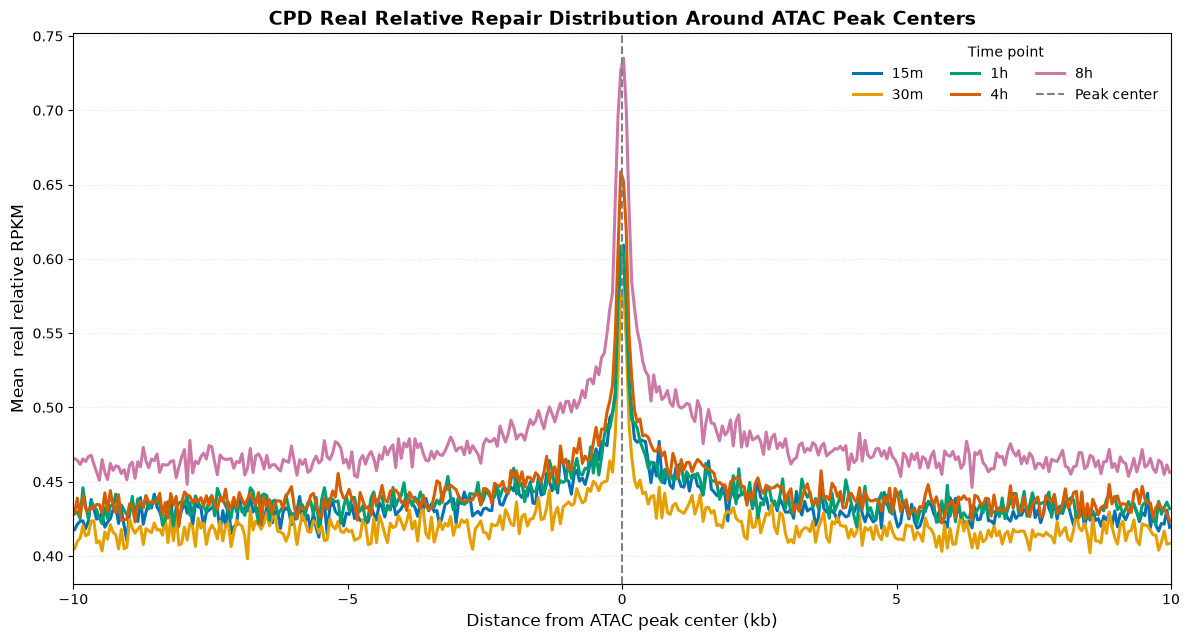

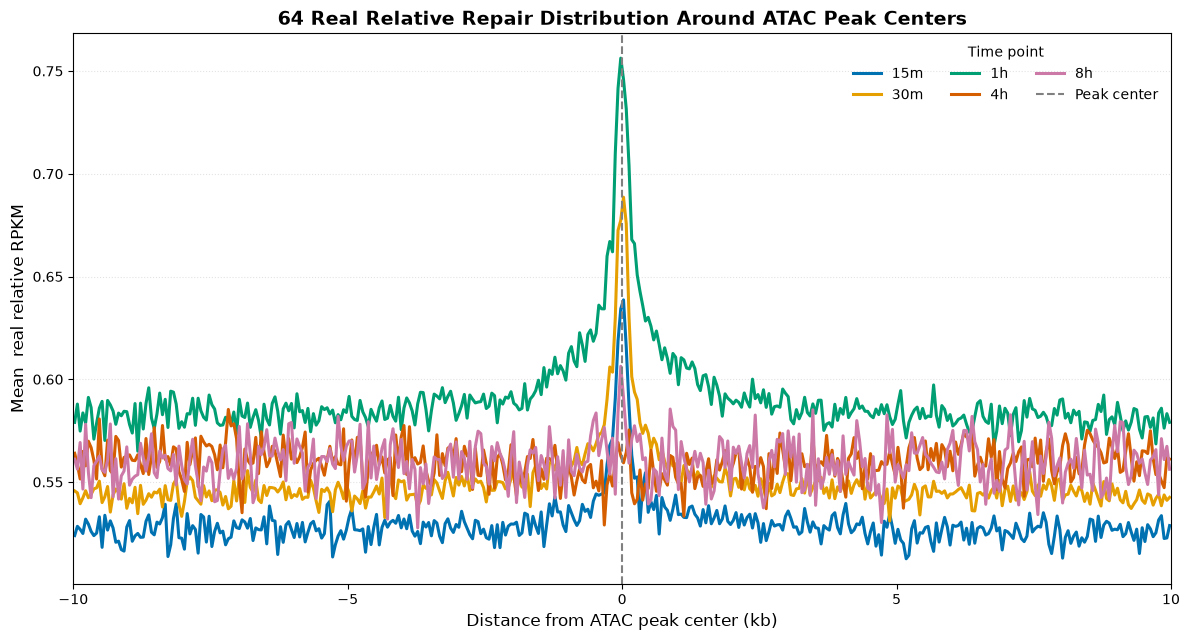

In [5]:
cpd_tables = {'15m': cpd_15m, '30m': cpd_30m, '1h': cpd_1h, '4h': cpd_4h, '8h': cpd_8h}
damage64_tables = {'15m': damage64_15m, '30m': damage64_30m, '1h': damage64_1h, '4h': damage64_4h, '8h': damage64_8h}

colors = {
    '15m': '#0072B2',
    '30m': '#E69F00',
    '1h': '#009E73',
    '4h': '#D55E00',
    '8h': '#CC79A7'
}

for title, tables in [('CPD', cpd_tables), ('64', damage64_tables)]:
    plt.figure(figsize=(12, 6.5))

    for timepoint, table in tables.items():
        distance_kb = (table['window'] - 200.5) * 0.05

        plt.plot(
            distance_kb,
            table['real_mean'],
            color=colors[timepoint],
            linewidth=2.2,
            label=timepoint
        )

    plt.axvline(
        x=0,
        color='gray',
        linestyle='--',
        linewidth=1.5,
        label='Peak center'
    )

    plt.xlim(-10, 10)
    plt.xticks([-10, -5, 0, 5, 10])

    plt.xlabel('Distance from ATAC peak center (kb)', fontsize=12)
    plt.ylabel(
        'Mean  real relative RPKM',
        fontsize=12
    )
    plt.title(
        f'{title} Real Relative Repair Distribution Around ATAC Peak Centers',
        fontsize=14,
        fontweight='bold'
    )

    plt.grid(axis='y', linestyle=':', alpha=0.35)
    plt.legend(
        title='Time point',
        frameon=False,
        ncol=3
    )
    plt.tight_layout()

    plt.savefig(
        f'{folder}/{title}_window_mean_real.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

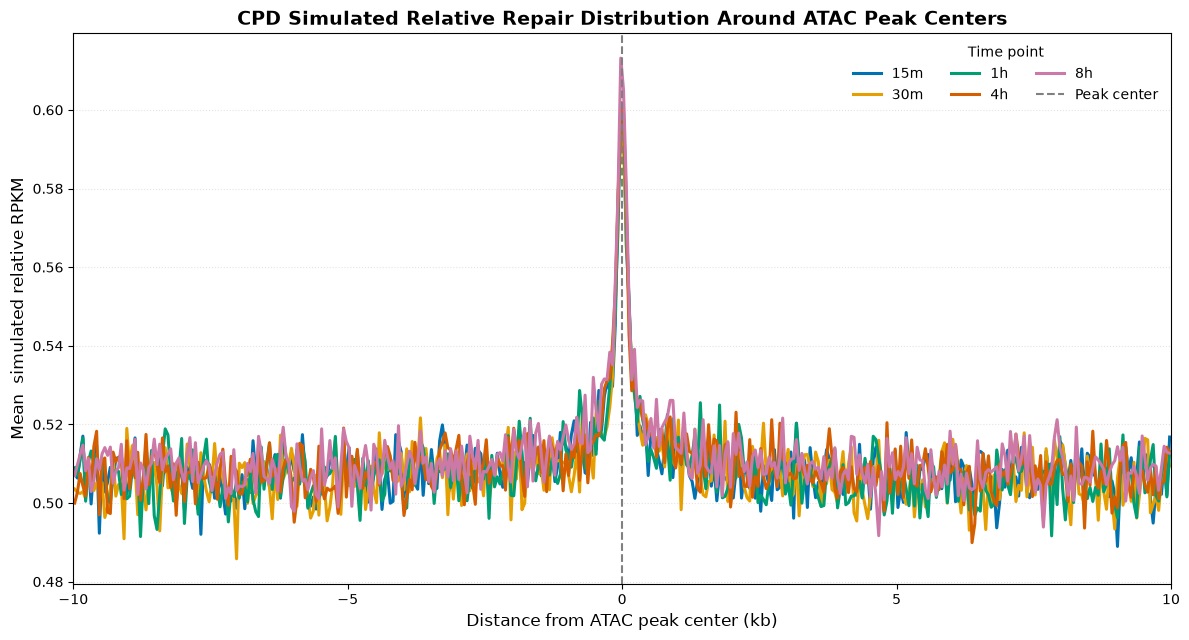

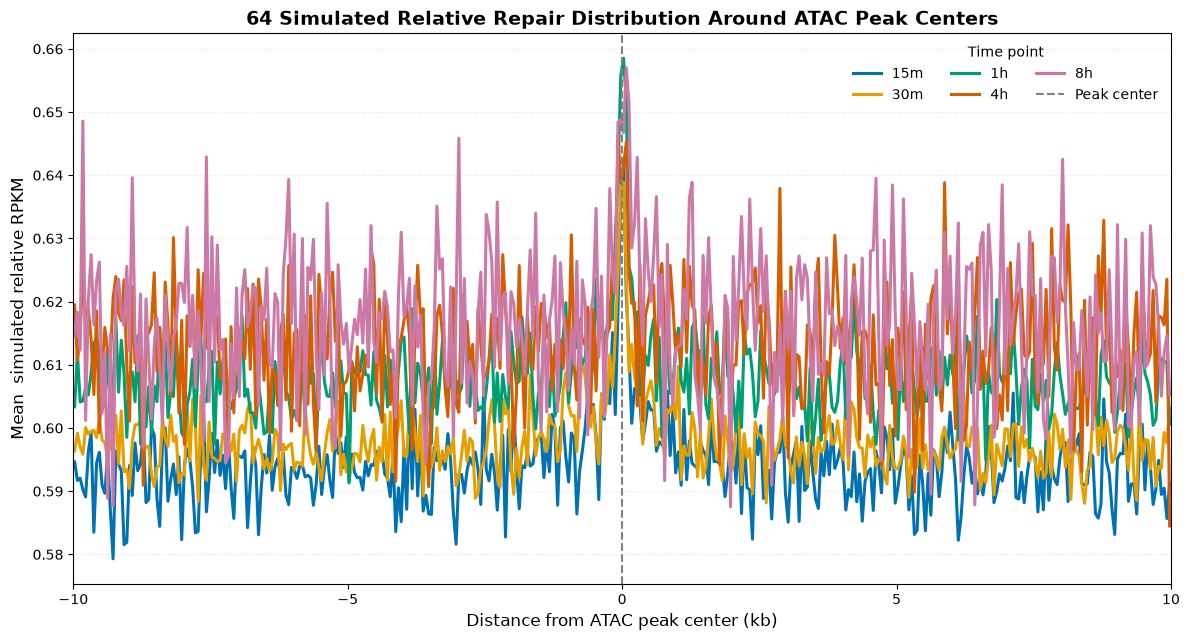

In [6]:
cpd_tables = {'15m': cpd_15m, '30m': cpd_30m, '1h': cpd_1h, '4h': cpd_4h, '8h': cpd_8h}
damage64_tables = {'15m': damage64_15m, '30m': damage64_30m, '1h': damage64_1h, '4h': damage64_4h, '8h': damage64_8h}

colors = {
    '15m': '#0072B2',
    '30m': '#E69F00',
    '1h': '#009E73',
    '4h': '#D55E00',
    '8h': '#CC79A7'
}

for title, tables in [('CPD', cpd_tables), ('64', damage64_tables)]:
    plt.figure(figsize=(12, 6.5))

    for timepoint, table in tables.items():
        distance_kb = (table['window'] - 200.5) * 0.05

        plt.plot(
            distance_kb,
            table['sim_mean'],
            color=colors[timepoint],
            linewidth=2.2,
            label=timepoint
        )

    plt.axvline(
        x=0,
        color='gray',
        linestyle='--',
        linewidth=1.5,
        label='Peak center'
    )

    plt.xlim(-10, 10)
    plt.xticks([-10, -5, 0, 5, 10])

    plt.xlabel('Distance from ATAC peak center (kb)', fontsize=12)
    plt.ylabel(
        'Mean  simulated relative RPKM',
        fontsize=12
    )
    plt.title(
        f'{title} Simulated Relative Repair Distribution Around ATAC Peak Centers',
        fontsize=14,
        fontweight='bold'
    )

    plt.grid(axis='y', linestyle=':', alpha=0.35)
    plt.legend(
        title='Time point',
        frameon=False,
        ncol=3
    )
    plt.tight_layout()

    plt.savefig(
        f'{folder}/{title}_window_mean_sim.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()